/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_95553/3422857669.py:30: UserWarning: You passed a edgecolor/edgecolors ('#000000') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == class_value, 0], X[y == class_value, 1],


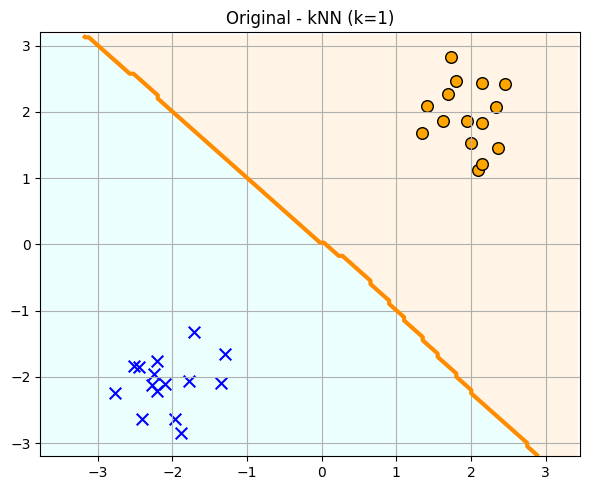

/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_95553/3422857669.py:30: UserWarning: You passed a edgecolor/edgecolors ('#000000') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == class_value, 0], X[y == class_value, 1],


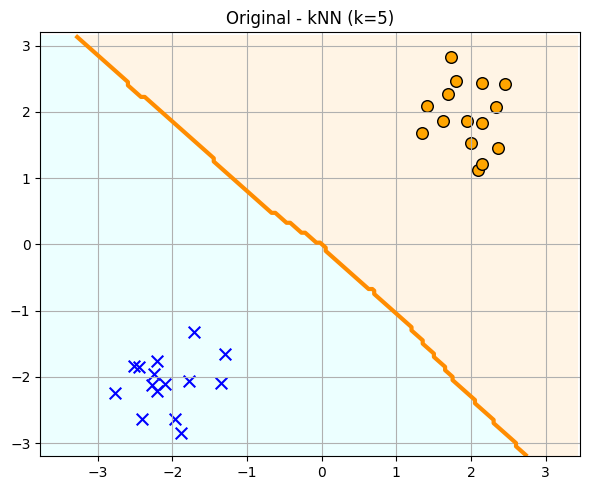

/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_95553/3422857669.py:30: UserWarning: You passed a edgecolor/edgecolors ('#000000') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == class_value, 0], X[y == class_value, 1],


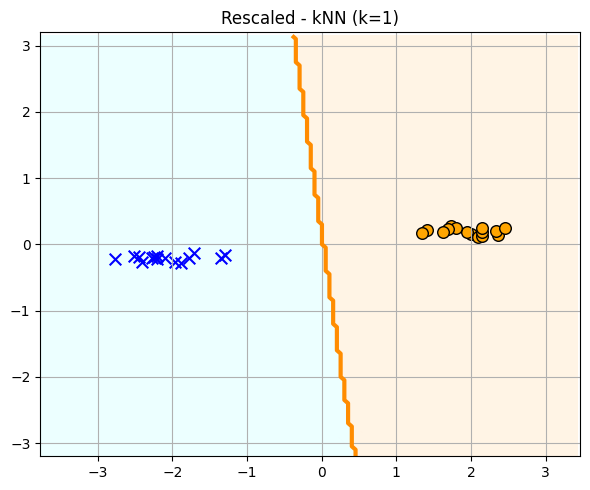

/var/folders/rs/z4yf99dx0wx_lqfdhc3l3dt40000gn/T/ipykernel_95553/3422857669.py:30: UserWarning: You passed a edgecolor/edgecolors ('#000000') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X[y == class_value, 0], X[y == class_value, 1],


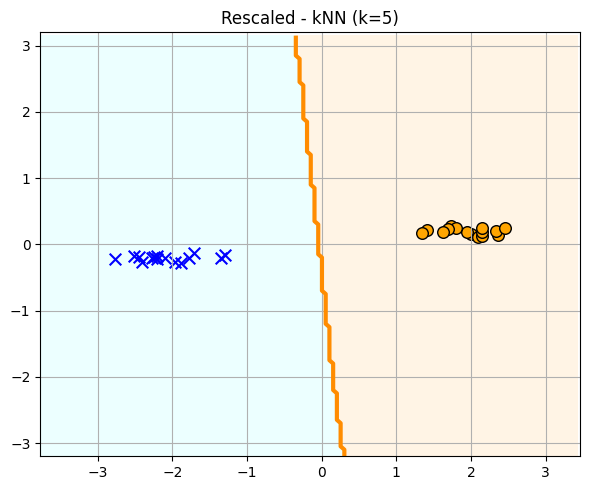

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

# Color setup
orange = "#FFA500"
blue = "#0000FF"
light_orange = "#FFEDD5"
light_blue = "#E0FFFF"
dark_orange = "#FF8C00"
black = "#000000"
background_cmap = ListedColormap([light_blue, light_orange])

def plot_knn_decision_boundary(X, y, k, xlim, ylim, title=""):
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X, y)

    h = 0.05
    xx, yy = np.meshgrid(np.arange(xlim[0], xlim[1], h),
                         np.arange(ylim[0], ylim[1], h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, cmap=background_cmap, alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors=[dark_orange], linewidths=3)

    for class_value, marker, color in zip([0, 1], ['x', 'o'], [blue, orange]):
        plt.scatter(X[y == class_value, 0], X[y == class_value, 1],
                    c=color, marker=marker, edgecolor=black, s=70)

    plt.title(title)
    plt.xlim(xlim)
    plt.ylim(ylim)
    # plt.xlabel("Feature 1")
    # plt.ylabel("Feature 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Generate diagonal-aligned data
np.random.seed(42)
class0 = np.random.multivariate_normal([-2, -2], [[0.2, 0], [0, 0.2]], size=15)
class1 = np.random.multivariate_normal([2, 2], [[0.2, 0], [0, 0.2]], size=15)
X_orig = np.vstack([class0, class1])
y = np.array([0]*15 + [1]*15)

# Rescale feature 2 (vertical axis)
X_scaled = X_orig.copy()
X_scaled[:, 1] *= .1  # Large change

# Plot both versions
for label, X_plot in [("Original", X_orig), ("Rescaled", X_scaled)]:
    x_margin, y_margin = 1.0, 1.0
    x_min, x_max = X_plot[:, 0].min() - x_margin, X_plot[:, 0].max() + x_margin
    y_min, y_max = X_plot[:, 1].min() - y_margin, X_plot[:, 1].max() + y_margin
    xlim, ylim = (x_min, x_max), (y_min, y_max)
    ylim = -3.2, 3.2

    plot_knn_decision_boundary(X_plot, y, k=1, xlim=xlim, ylim=ylim,
                               title=f"{label} - kNN (k=1)")
    plot_knn_decision_boundary(X_plot, y, k=5, xlim=xlim, ylim=ylim,
                               title=f"{label} - kNN (k=5)")